# K-Nearest Neighbors (KNN)

=== Comparison of KNN Varieties ===


,KNN Variety,Test Accuracy


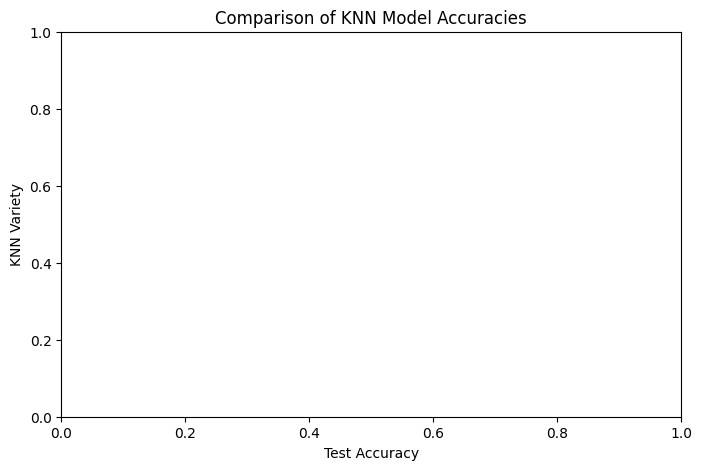

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store comparison results - ensure it's initialized
comparison = {}

print("=== Comparison of KNN Varieties ===")
comparison_df = pd.DataFrame(list(comparison.items()), columns=['KNN Variety', 'Test Accuracy'])
display(comparison_df.sort_values(by='Test Accuracy', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Test Accuracy', y='KNN Variety', data=comparison_df.sort_values(by='Test Accuracy', ascending=False), palette='viridis')
plt.title('Comparison of KNN Model Accuracies')
plt.xlabel('Test Accuracy')
plt.ylabel('KNN Variety')
plt.xlim(0, 1)
plt.show()

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
)

Load Data

In [4]:
df = pd.read_csv("../../results/outputs/final_preprocessed_telco_data_new.csv")

In [5]:
display(df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Churn
0,-2.839944,-1.247643,1.014425,-0.339953,-1.099294,0.092576,0.517341,0.408477,-0.086671,-0.036771,0
1,-0.352317,1.434602,-0.451466,-0.359328,0.000225,-0.189705,-0.298579,-0.370672,-0.114527,0.056526,0
2,-2.088348,-0.190338,-1.506188,-1.079722,-0.208352,-0.238015,0.160883,-0.210342,0.153532,0.008629,1
3,-0.375654,1.872523,-0.302458,-0.423412,-0.256734,-0.361657,-0.244218,0.374798,0.185815,0.003063,0
4,-1.362409,-2.841712,0.577507,0.012427,0.531640,0.700028,0.178311,-0.106544,0.143042,-0.114418,1


In [6]:
# Define features & target
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# Feature Scaling (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Dictionary to store comparison results
comparison = {}

Part 1: Uniform KNN (Euclidean)

In [10]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn1 = KNeighborsClassifier(weights='uniform', metric='euclidean')
grid_search1 = GridSearchCV(knn1, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search1.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,KNeighborsCla...c='euclidean')
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [11]:
best_knn1 = grid_search1.best_estimator_
y_pred1 = best_knn1.predict(X_test_scaled)
acc1 = accuracy_score(y_test, y_pred1)
comparison['Uniform KNN (Euclidean)'] = acc1

In [12]:
print(f"Best n_neighbors: {grid_search1.best_params_['n_neighbors']}")
print(f"Test Accuracy: {acc1:.4f}")
print(classification_report(y_test, y_pred1))

Best n_neighbors: 11
Test Accuracy: 0.7786
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



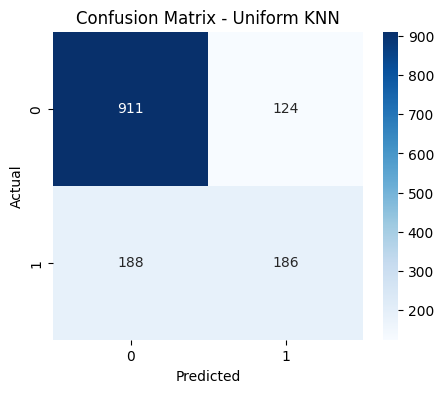

In [13]:
# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(5,4))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Uniform KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

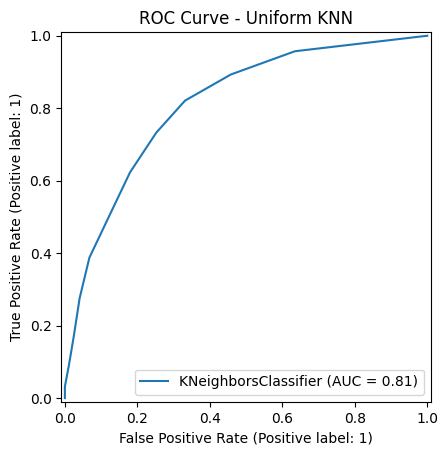

In [14]:
# ROC Curve
RocCurveDisplay.from_estimator(best_knn1, X_test_scaled, y_test)
plt.title("ROC Curve - Uniform KNN")
plt.show()

Part 2: Distance-Weighted KNN

In [15]:
knn2 = KNeighborsClassifier(weights='distance', metric='euclidean')
grid_search2 = GridSearchCV(knn2, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search2.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,KNeighborsCla...ts='distance')
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [16]:
best_knn2 = grid_search2.best_estimator_
y_pred2 = best_knn2.predict(X_test_scaled)
acc2 = accuracy_score(y_test, y_pred2)
comparison['Distance-Weighted KNN'] = acc2

In [17]:
print(f"Best n_neighbors: {grid_search2.best_params_['n_neighbors']}")
print(f"Test Accuracy: {acc2:.4f}")
print(classification_report(y_test, y_pred2))


Best n_neighbors: 11
Test Accuracy: 0.7764
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



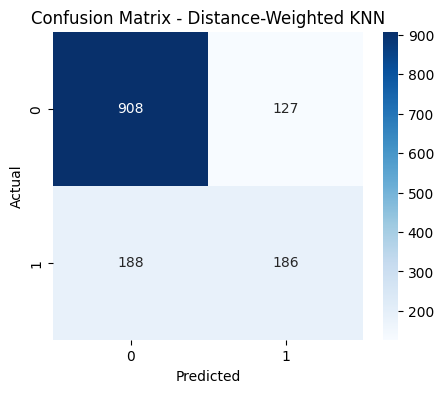

In [18]:
# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Distance-Weighted KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

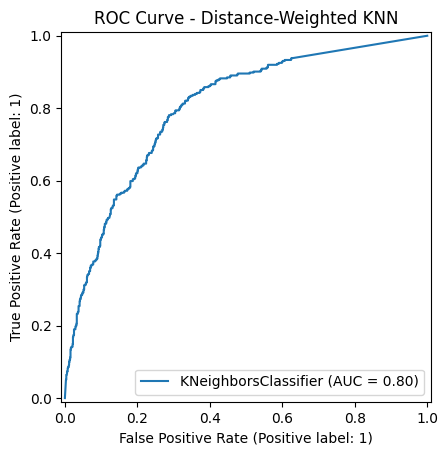

In [19]:
# ROC Curve
RocCurveDisplay.from_estimator(best_knn2, X_test_scaled, y_test)
plt.title("ROC Curve - Distance-Weighted KNN")
plt.show()

Part 3: Manhattan Distance KNN

In [20]:
knn3 = KNeighborsClassifier(weights='uniform', metric='manhattan')
grid_search3 = GridSearchCV(knn3, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search3.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,KNeighborsCla...c='manhattan')
,param_grid,"{'n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,11


In [21]:
best_knn3 = grid_search3.best_estimator_
y_pred3 = best_knn3.predict(X_test_scaled)
acc3 = accuracy_score(y_test, y_pred3)
comparison['Manhattan Distance KNN'] = acc3

In [22]:
print(f"Best n_neighbors: {grid_search3.best_params_['n_neighbors']}")
print(f"Test Accuracy: {acc3:.4f}")
print(classification_report(y_test, y_pred3))

Best n_neighbors: 11
Test Accuracy: 0.7757
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409



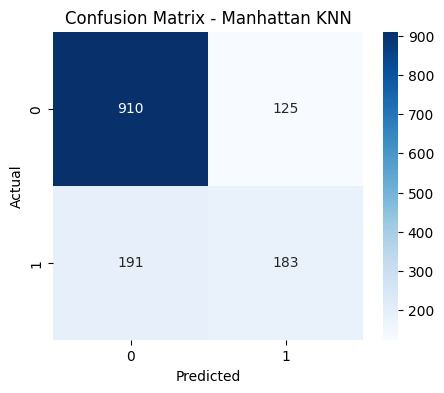

In [23]:
# Confusion Matrix
cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(5,4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Manhattan KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

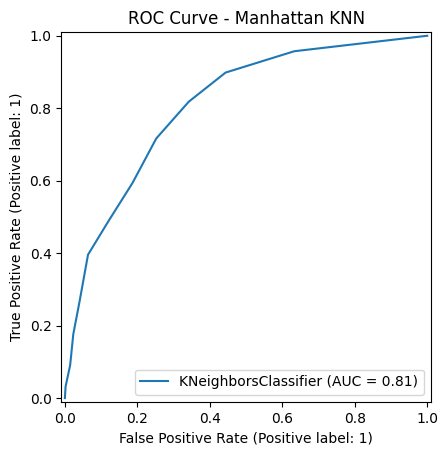

In [24]:
# ROC Curve
RocCurveDisplay.from_estimator(best_knn3, X_test_scaled, y_test)
plt.title("ROC Curve - Manhattan KNN")
plt.show()

Comparison of All Models

=== Comparison of KNN Varieties ===


,KNN Variety,Test Accuracy
0,Uniform KNN (Euclidean),0.778566
1,Distance-Weighted KNN,0.776437
2,Manhattan Distance KNN,0.775727


C:\Users\USER\AppData\Local\Temp\ipykernel_13788\1361279728.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test Accuracy', y='KNN Variety', data=comparison_df.sort_values(by='Test Accuracy', ascending=False), palette='viridis')


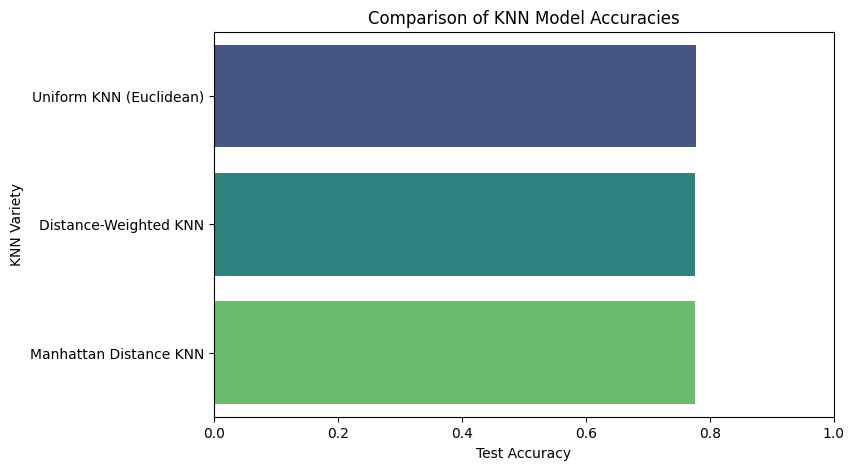

In [25]:
print("=== Comparison of KNN Varieties ===")
comparison_df = pd.DataFrame(list(comparison.items()), columns=['KNN Variety', 'Test Accuracy'])
display(comparison_df.sort_values(by='Test Accuracy', ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x='Test Accuracy', y='KNN Variety', data=comparison_df.sort_values(by='Test Accuracy', ascending=False), palette='viridis')
plt.title('Comparison of KNN Model Accuracies')
plt.xlabel('Test Accuracy')
plt.ylabel('KNN Variety')
plt.xlim(0, 1)
plt.show()